In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("All libraries loaded ")

All libraries loaded 


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train fraud %: {y_train.mean()*100:.1f}%")
print(f"y_test  fraud %: {y_test.mean()*100:.4f}%")

X_train: (454902, 14)
X_test:  (56962, 14)
y_train fraud %: 50.0%
y_test  fraud %: 0.1720%


In [3]:
def evaluate_model(name, model, X_test, y_test):
    """Evaluate model and return metrics dict."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Model":     name,
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
    }
    return metrics, y_pred, y_prob


def plot_confusion_matrix(name, y_test, y_pred, ax):
    """Plot confusion matrix on given axis."""
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'], ax=ax)
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')


print("Helper functions ready ")

Helper functions ready 


In [4]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train, y_train)

lr_metrics, lr_pred, lr_prob = evaluate_model("Logistic Regression", lr, X_test, y_test)
print(f" ROC-AUC: {lr_metrics['ROC-AUC']}")
print(f" F1:      {lr_metrics['F1-Score']}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Fraud']))

Training Logistic Regression...
 ROC-AUC: 0.9705
 F1:      0.0955

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     56864
       Fraud       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [5]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

rf_metrics, rf_pred, rf_prob = evaluate_model("Random Forest", rf, X_test, y_test)
print(f" ROC-AUC: {rf_metrics['ROC-AUC']}")
print(f" F1:      {rf_metrics['F1-Score']}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Fraud']))

Training Random Forest...
 ROC-AUC: 0.9777
 F1:      0.4521

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.87      0.45        98

    accuracy                           1.00     56962
   macro avg       0.65      0.93      0.73     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
print("Training XGBoost...")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_metrics, xgb_pred, xgb_prob = evaluate_model("XGBoost", xgb, X_test, y_test)
print(f" ROC-AUC: {xgb_metrics['ROC-AUC']}")
print(f" F1:      {xgb_metrics['F1-Score']}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Normal', 'Fraud']))

Training XGBoost...
 ROC-AUC: 0.9813
 F1:      0.4943

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.34      0.88      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.94      0.75     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:
print("Training LightGBM...")

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)
lgbm.fit(X_train, y_train)

lgbm_metrics, lgbm_pred, lgbm_prob = evaluate_model("LightGBM", lgbm, X_test, y_test)
print(f" ROC-AUC: {lgbm_metrics['ROC-AUC']}")
print(f" F1:      {lgbm_metrics['F1-Score']}")
print(f"\nClassification Report:")
print(classification_report(y_test, lgbm_pred, target_names=['Normal', 'Fraud']))

Training LightGBM...
 ROC-AUC: 0.9391
 F1:      0.4538

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.83      0.45        98

    accuracy                           1.00     56962
   macro avg       0.66      0.91      0.73     56962
weighted avg       1.00      1.00      1.00     56962



MODEL COMPARISON
              Model  ROC-AUC  F1-Score  Precision  Recall
            XGBoost   0.9813    0.4943     0.3440  0.8776
      Random Forest   0.9777    0.4521     0.3058  0.8673
Logistic Regression   0.9705    0.0955     0.0504  0.9184
           LightGBM   0.9391    0.4538     0.3127  0.8265


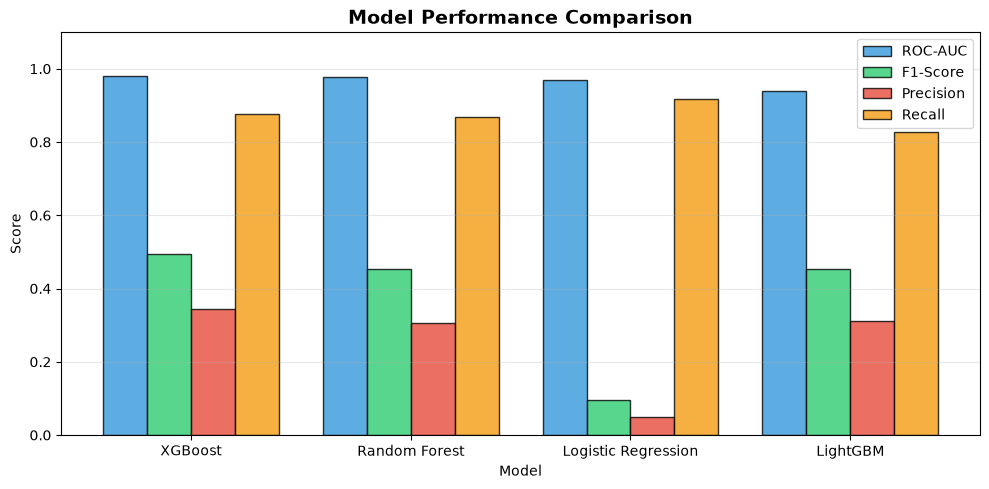

In [8]:
results = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics, lgbm_metrics])
results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
width = 0.2

metrics_to_plot = ['ROC-AUC', 'F1-Score', 'Precision', 'Recall']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, results[metric], width, 
                  label=metric, color=color, edgecolor='black', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

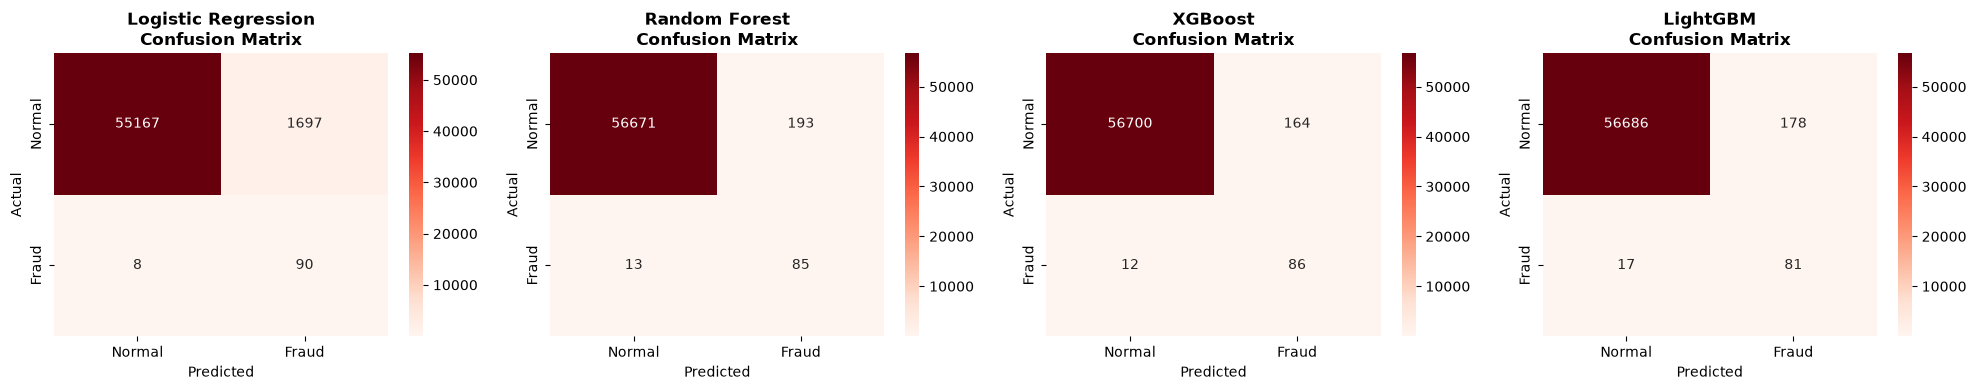

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

plot_confusion_matrix("Logistic Regression", y_test, lr_pred, axes[0])
plot_confusion_matrix("Random Forest", y_test, rf_pred, axes[1])
plot_confusion_matrix("XGBoost", y_test, xgb_pred, axes[2])
plot_confusion_matrix("LightGBM", y_test, lgbm_pred, axes[3])

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

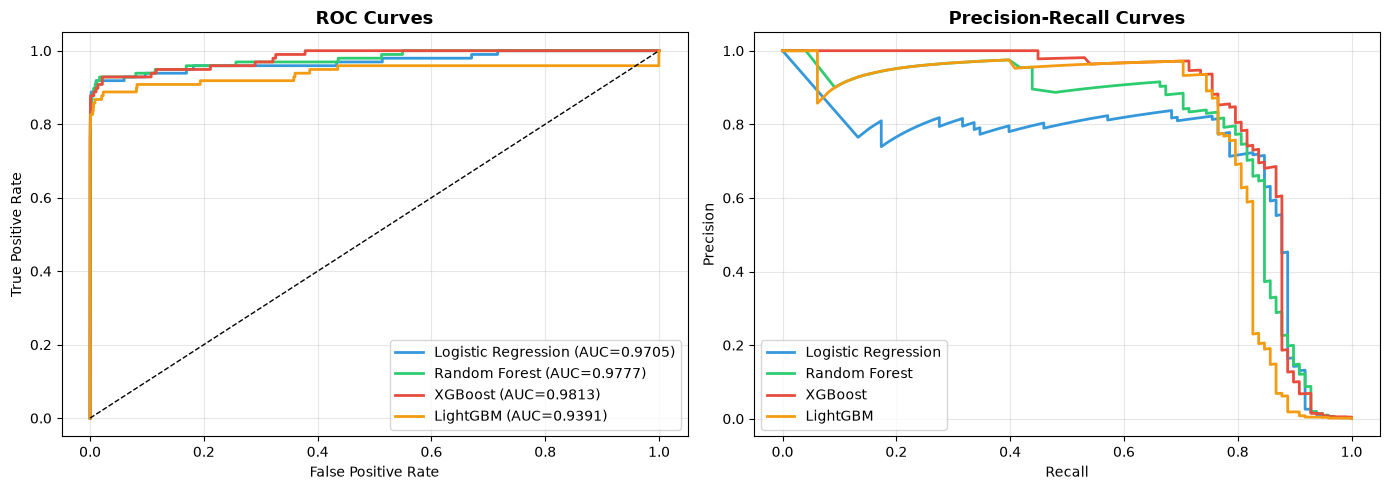

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
models_data = [
    ("Logistic Regression", lr_prob, '#3498db'),
    ("Random Forest", rf_prob, '#2ecc71'),
    ("XGBoost", xgb_prob, '#e74c3c'),
    ("LightGBM", lgbm_prob, '#f39c12'),
]

for name, prob, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1], [0,1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
for name, prob, color in models_data:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(recall, precision, color=color, linewidth=2, label=name)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

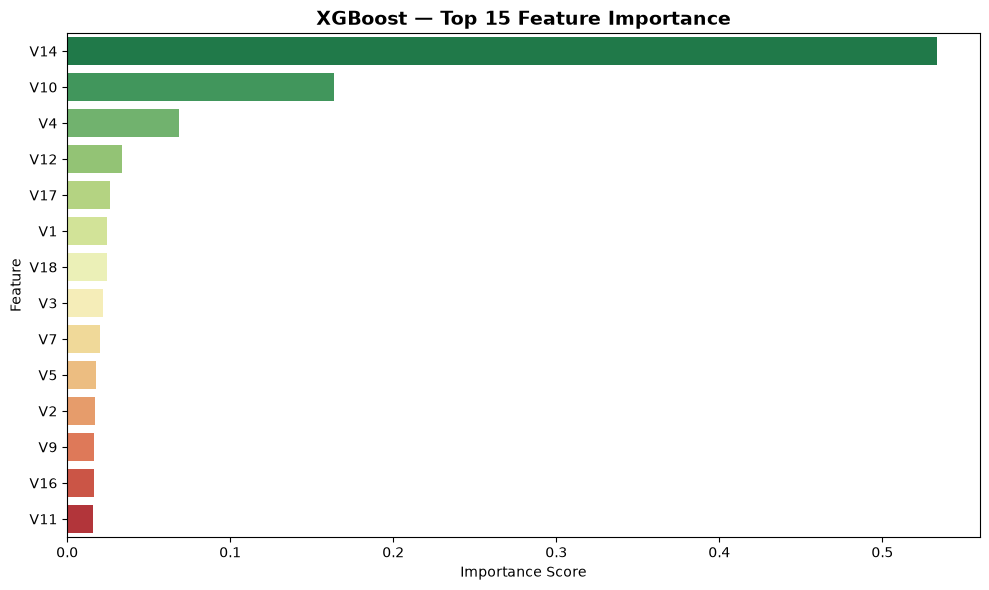

Top 5 most important features:
  Feature  Importance
1     V14    0.533230
3     V10    0.163933
8      V4    0.068329
2     V12    0.033638
0     V17    0.026568


In [11]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            palette='RdYlGn_r')
plt.title('XGBoost — Top 15 Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(importance_df.head())

In [12]:
# Identify best model by ROC-AUC
best_model_name = results.iloc[0]['Model']
best_model_map = {
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "Random Forest": rf,
    "Logistic Regression": lr,
}
best_model = best_model_map[best_model_name]

# Save model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature list
with open('../models/selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

print(f" Best model: {best_model_name}")
print(f" Saved to models/best_model.pkl")

# Save metrics
results.to_csv('../models/model_metrics.csv', index=False)
print(f" Metrics saved to models/model_metrics.csv")

 Best model: XGBoost
 Saved to models/best_model.pkl
 Metrics saved to models/model_metrics.csv


In [13]:
best = results.iloc[0]
print("=" * 60)
print("MODELING SUMMARY")
print("=" * 60)
print(f"""
Models Trained:
  1. Logistic Regression  — Baseline
  2. Random Forest        — Ensemble  
  3. XGBoost              — Gradient Boosting
  4. LightGBM             — Fast Gradient Boosting

Best Model: {best['Model']}
  ROC-AUC:   {best['ROC-AUC']}
  F1-Score:  {best['F1-Score']}
  Precision: {best['Precision']}
  Recall:    {best['Recall']}

Key Insights:
  - SMOTE effectively balanced the training data
  - Tree-based models outperform Logistic Regression
  - XGBoost/LightGBM best for imbalanced fraud data
  - V14, V4, V11 are most predictive features

Next Step: FastAPI backend + LLM Explainer
""")

MODELING SUMMARY

Models Trained:
  1. Logistic Regression  — Baseline
  2. Random Forest        — Ensemble  
  3. XGBoost              — Gradient Boosting
  4. LightGBM             — Fast Gradient Boosting

Best Model: XGBoost
  ROC-AUC:   0.9813
  F1-Score:  0.4943
  Precision: 0.344
  Recall:    0.8776

Key Insights:
  - SMOTE effectively balanced the training data
  - Tree-based models outperform Logistic Regression
  - XGBoost/LightGBM best for imbalanced fraud data
  - V14, V4, V11 are most predictive features

Next Step: FastAPI backend + LLM Explainer

